In [1]:
import sys

import numpy as np
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# 'models' o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"
MODELS_DIR = SOLUTION_DIR / "models"
DENSE_DIR = MODELS_DIR / "dense"

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que se
# importan desde su carpeta. iSpec tampoco se instala como dependencia, pero de
# montarlo se encarga 'iSpec_functions', que lo añade a 'sys.path' al importarse.
sys.path.insert(0, str(MODELS_DIR))

# Ficheros de checkpoint, cuatro por modelo. Cada modelo lleva su propio `.npz`
# de test porque cada uno usa una normalización distinta. Esta celda no carga
# datos, de modo que la recarga de una sesión anterior solo necesita ejecutar
# esta celda y la de recarga del modelo que interese.
DENSE_DIR.mkdir(exist_ok=True)

GLOBAL_MODEL_PATH = DENSE_DIR / "dense-global.keras"
GLOBAL_HISTORY_PATH = DENSE_DIR / "dense-global_training_history.csv"
GLOBAL_SUMMARY_PATH = DENSE_DIR / "dense-global_training_summary.json"
GLOBAL_TEST_DATA_PATH = DENSE_DIR / "dense-global_test_data.npz"

MEDIAN_MODEL_PATH = DENSE_DIR / "dense-median.keras"
MEDIAN_HISTORY_PATH = DENSE_DIR / "dense-median_training_history.csv"
MEDIAN_SUMMARY_PATH = DENSE_DIR / "dense-median_training_summary.json"
MEDIAN_TEST_DATA_PATH = DENSE_DIR / "dense-median_test_data.npz"

MAX_MODEL_PATH = DENSE_DIR / "dense-max.keras"
MAX_HISTORY_PATH = DENSE_DIR / "dense-max_training_history.csv"
MAX_SUMMARY_PATH = DENSE_DIR / "dense-max_training_summary.json"
MAX_TEST_DATA_PATH = DENSE_DIR / "dense-max_test_data.npz"

# Predicciones sobre el conjunto de test. No son un checkpoint del
# entrenamiento, sino el dato que consume la comparativa entre arquitecturas,
# así que van en 'data/predictions' y no en la carpeta del cuaderno.
PREDICTIONS_DIR = DATA_DIR / "predictions"

GLOBAL_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-global_predictions.npz"
MEDIAN_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-median_predictions.npz"
MAX_PREDICTIONS_PATH = PREDICTIONS_DIR / "dense-max_predictions.npz"

# Tamaño de lote del entrenamiento, guardado también en cada resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

2026-08-31 23:59:41.969000: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-31 23:59:42.758283: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-31 23:59:47.175274: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [4]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm_global = (X_train - X_mean) / X_std
X_val_norm_global = (X_val - X_mean) / X_std
X_test_norm_global = (X_test - X_mean) / X_std

y_train_norm_global = (y_train - y_mean) / y_std
y_val_norm_global = (y_val - y_mean) / y_std
y_test_norm_global = (y_test - y_mean) / y_std

In [5]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    GLOBAL_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_mean=X_mean,
    X_std=X_std,
    y_mean=y_mean,
    y_std=y_std
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global_test_data.npz')

In [6]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos la estructura del modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

2026-09-01 00:00:00.651873: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

El entrenamiento de cada modelo deja en `models/dense` cuatro ficheros de checkpoint, uno por cada forma de dato, con los que las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `<modelo>.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `<modelo>_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre normalizaciones. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `<modelo>_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `<modelo>_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores (`X_test`, `y_test`, los identificadores, las longitudes de onda y los estadísticos de la normalización). Son **arrays** de cientos de megabytes, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

Cada modelo lleva su propio `.npz` porque cada uno normaliza el conjunto de test de una forma distinta. La lógica de guardado y recarga vive en `models/services/checkpoints.py`, compartida por todos los cuadernos de entrenamiento. La normalización del conjunto de test no se guarda: se rehace a partir de sus estadísticos. De las predicciones se ocupa `models/services/predictions.py`, que las guarda aparte, en `data/predictions/<modelo>_predictions.npz`: no son un checkpoint del entrenamiento sino el dato que consume la comparativa entre arquitecturas.

In [8]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_global = ModelCheckpoint(
    GLOBAL_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_global = CSVLogger(GLOBAL_HISTORY_PATH)

history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_global,
        early_stop,
        reduce_lr,
        save_training_history_global
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model.save(GLOBAL_MODEL_PATH)

model_data_norm_global = history_norm_global.history
save_training_summary(
    GLOBAL_SUMMARY_PATH,
    model_data_norm_global,
    model_path=GLOBAL_MODEL_PATH,
    history_path=GLOBAL_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0275 - mae: 0.1297 - mse: 0.0626
Epoch 1: val_loss improved from None to 0.01325, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - loss: 0.0275 - mae: 0.1297 - mse: 0.0625 - val_loss: 0.0133 - val_mae: 0.0920 - val_mse: 0.0286 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0127 - mae: 0.0923 - mse: 0.0275
Epoch 2: val_loss improved from 0.01325 to 0.01289, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-global.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - loss: 0.012

{'model': 'dense-global.keras',
 'history': 'dense-global_training_history.csv',
 'updated': '2026-09-01T00:14:43',
 'batch_size': 64,
 'epochs_completed': 24,
 'best_epoch': 23,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización global. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [9]:
from services.checkpoints import load_checkpoint, load_test_data

model, model_data_norm_global, summary_global = load_checkpoint(
    GLOBAL_MODEL_PATH, GLOBAL_HISTORY_PATH, GLOBAL_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(GLOBAL_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_mean = test_data["X_mean"]
X_std = test_data["X_std"]
y_mean = test_data["y_mean"]
y_std = test_data["y_std"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_global = (X_test - X_mean) / X_std
y_test_norm_global = (y_test - y_mean) / y_std

print("Checkpoint de", summary_global["updated"])
print(
    "Épocas completadas:", summary_global["epochs_completed"],
    "| mejor época:", summary_global["best_epoch"]
)
print("Métricas de test:", summary_global["test_metrics"])

Checkpoint de 2026-09-01T00:14:43
Épocas completadas: 24 | mejor época: 23
Métricas de test: None


Graficamos la evolución de las variables estudiadas en el modelo.

In [10]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

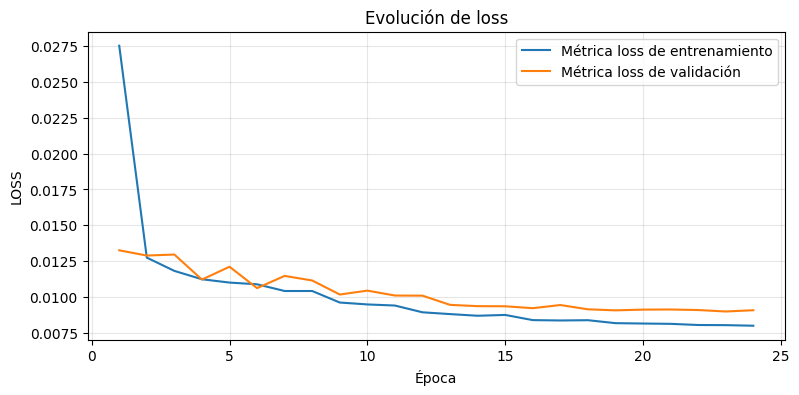

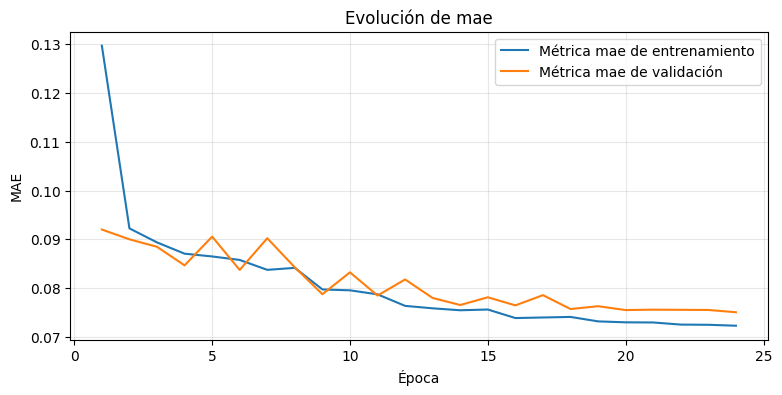

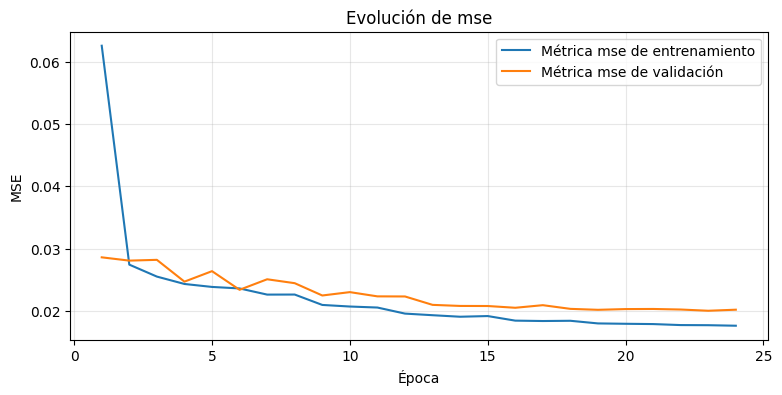

In [11]:
plot_training_metrics(model_data_norm_global)

In [ ]:
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización global. La celda parte del `.keras`
# del modelo y del `.npz` de test, así que se ejecuta suelta tras la de rutas:
# no reentrena, no vuelve a cargar el `.npz` de datos completo y no necesita las
# variables que dejen en memoria las demás celdas del cuaderno.
y_pred_global = predict_test_set(
    GLOBAL_MODEL_PATH,
    GLOBAL_TEST_DATA_PATH,
    build_input=lambda test: (test["X_test"] - test["X_mean"]) / test["X_std"],
    denormalize=lambda y_norm, test: y_norm * test["y_std"] + test["y_mean"]
)

# Las guardamos para la comparativa entre arquitecturas, en su propio cuaderno
save_predictions(GLOBAL_PREDICTIONS_PATH, y_pred=y_pred_global)

Graficamos un par de ejemplos

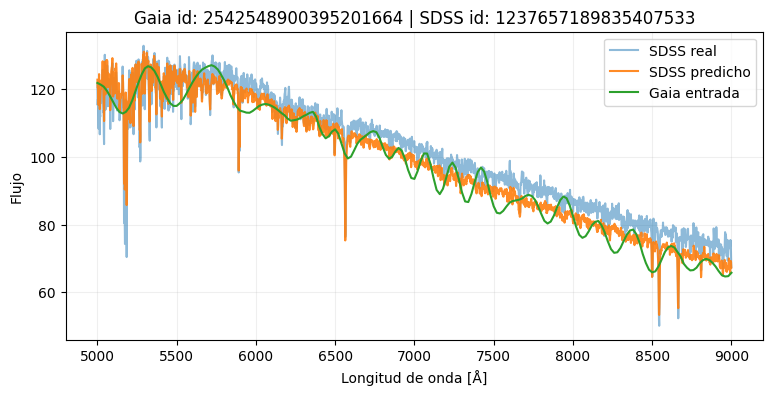

In [13]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

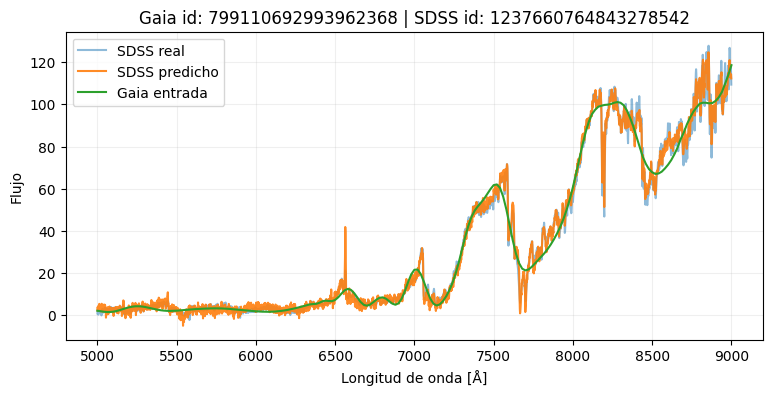

In [14]:
plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_global,
    y_id_test,
    X_test,
    X_id_test
)

In [15]:
from services.checkpoints import save_training_summary

test_results_global = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    GLOBAL_SUMMARY_PATH,
    model_data_norm_global,
    test_results_global,
    model_path=GLOBAL_MODEL_PATH,
    history_path=GLOBAL_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_global)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0098 - mae: 0.0779 - mse: 0.0212
{'loss': 0.009797128848731518, 'mae': 0.07787792384624481, 'mse': 0.021224206313490868}


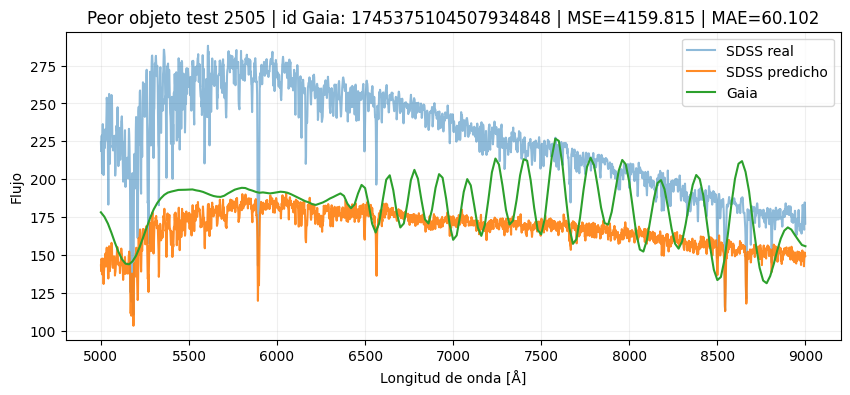

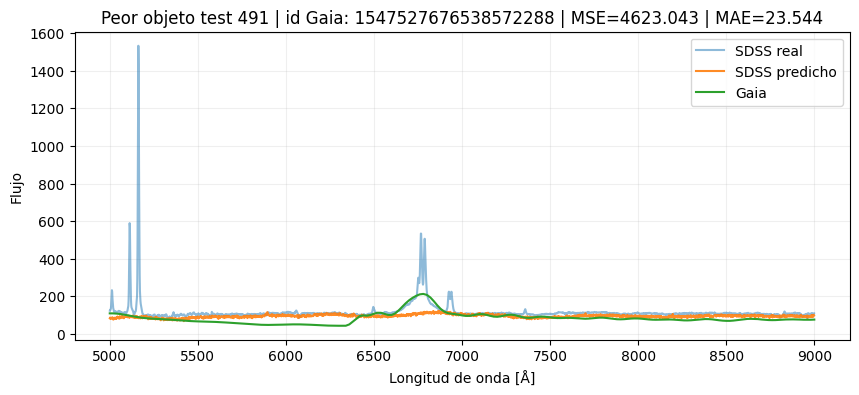

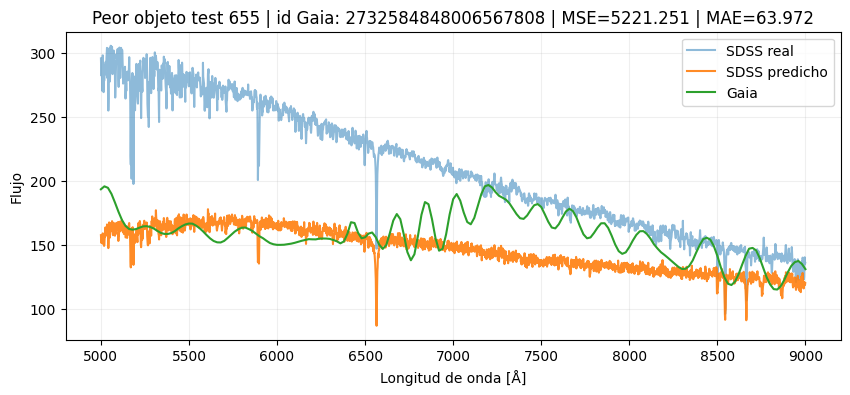

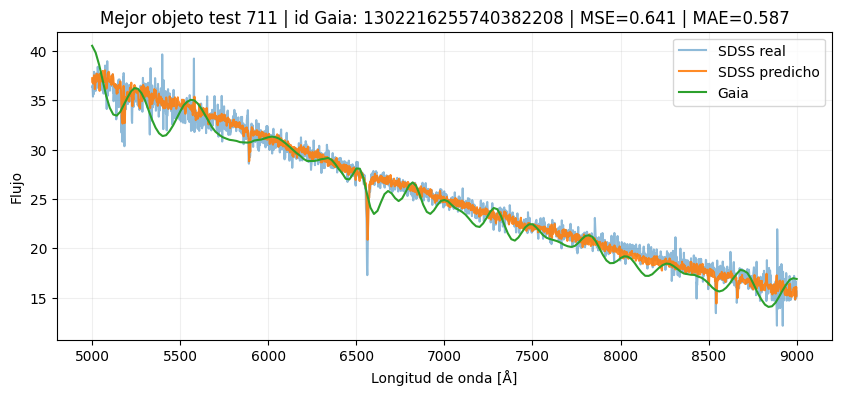

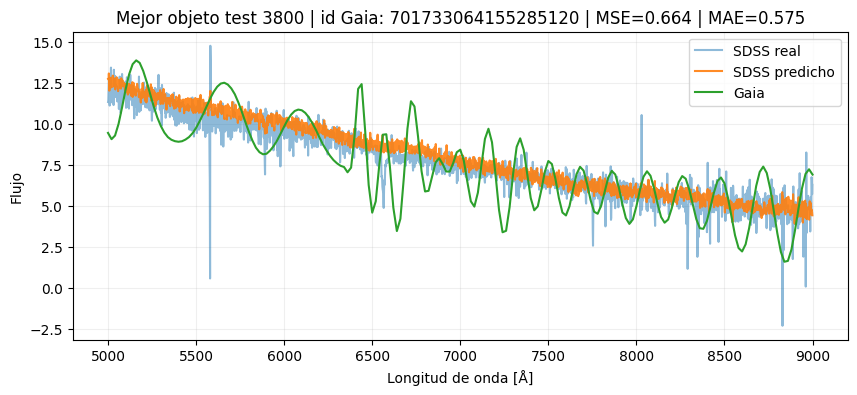

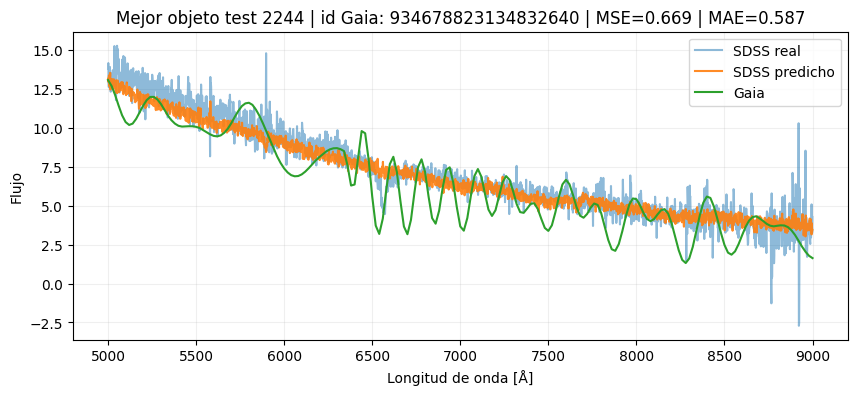

In [16]:
plot_worst_best_predictions(
    y_test,
    y_pred_global,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [17]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    load_gaia_table,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [18]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [19]:
# Cargamos Resources
resources = load_ispec_resources()

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.


In [20]:
# Cargamos la tabla de Gaia guardada en local
gaia_data_df = load_gaia_table()

Tabla de Gaia cargada: 121890 objetos.


In [21]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real







Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-09-01 03:28:32,982] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.6911155921887793 -4.559396401646449 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-01 03:28:34,090] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-01 03:28:40,302] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.9241712654505534 -4.433403594361867 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-01 03:28:41,413] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-01 03:28:48,655] [WARNING] [atmospheres:_interpolate:110]: Target point '3538.7181018573174 2.120410924434774 -4.114757058198167 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-2
. . . now exiting to system . . .
[2026-09-0

Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Espectros analizados: 250 | ajustes del espectro real reutilizados: 0


In [22]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5382.354575,4.723689,-0.915919,93.083187,0.048693,-0.010514
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5754.136718,4.679060,-1.115626,-8.071741,0.003750,0.010008
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6034.843961,4.165982,-0.689301,0.075737,0.000242,-0.000614
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6021.835732,4.361940,-0.649328,-32.696293,0.000371,0.242841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4816.996454,5.000000,-1.241689,24.472454,0.000000,0.150774
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5420.400645,4.722004,-0.989613,2.061984,0.002693,-0.000641
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5828.026052,4.587632,-0.950089,32.444465,-0.060124,0.021101
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5951.735045,4.758386,-2.069467,7.350408,0.051995,-0.131527


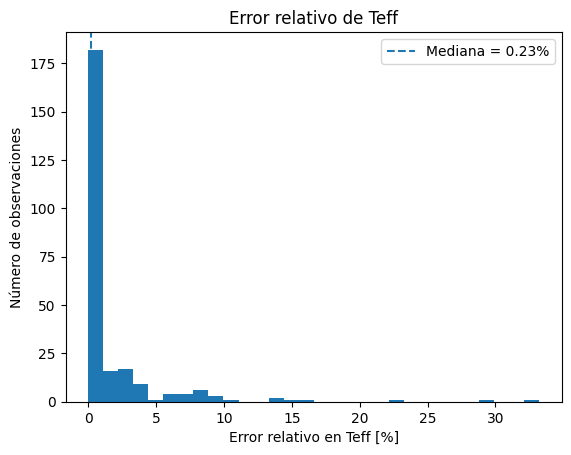

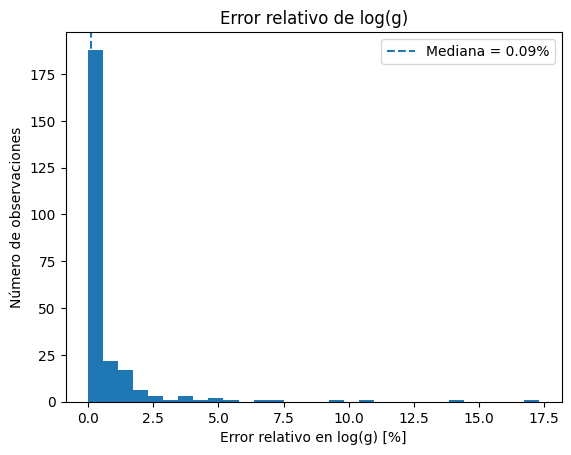

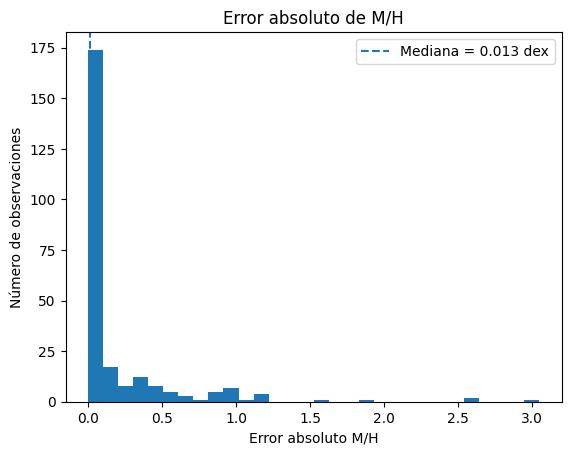

In [23]:
error_df = analyze_ispec_errors(results_df)

In [24]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5382.354575,4.723689,-0.915919,93.083187,0.048693,-0.010514,93.083187,0.048693,0.010514,1.759849,1.041552
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5754.136718,4.679060,-1.115626,-8.071741,0.003750,0.010008,8.071741,0.003750,0.010008,0.140081,0.080214
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6034.843961,4.165982,-0.689301,0.075737,0.000242,-0.000614,0.075737,0.000242,0.000614,0.001255,0.005820
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6021.835732,4.361940,-0.649328,-32.696293,0.000371,0.242841,32.696293,0.000371,0.242841,0.540030,0.008516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4816.996454,5.000000,-1.241689,24.472454,0.000000,0.150774,24.472454,0.000000,0.150774,0.510638,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5420.400645,4.722004,-0.989613,2.061984,0.002693,-0.000641,2.061984,0.002693,0.000641,0.038056,0.057055
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5828.026052,4.587632,-0.950089,32.444465,-0.060124,0.021101,32.444465,0.060124,0.021101,0.559814,1.293612
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5951.735045,4.758386,-2.069467,7.350408,0.051995,-0.131527,7.350408,0.051995,0.131527,0.123653,1.104770


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [25]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

In [26]:
# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    MEDIAN_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_scale_test=X_scale_test,
    y_scale_test=y_scale_test
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median_test_data.npz')

In [27]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_median_spec = ModelCheckpoint(
    MEDIAN_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_median_spec = CSVLogger(MEDIAN_HISTORY_PATH)

# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_median_spec,
        early_stop,
        reduce_lr,
        save_training_history_median_spec
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_median_spec.save(MEDIAN_MODEL_PATH)

model_data_median_spec = history.history
save_training_summary(
    MEDIAN_SUMMARY_PATH,
    model_data_median_spec,
    model_path=MEDIAN_MODEL_PATH,
    history_path=MEDIAN_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0189 - mae: 0.0916 - mse: 0.0436
Epoch 1: val_loss improved from None to 0.00475, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - loss: 0.0189 - mae: 0.0916 - mse: 0.0436 - val_loss: 0.0048 - val_mae: 0.0527 - val_mse: 0.0145 - learning_rate: 1.0000e-04
Epoch 2/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0046 - mae: 0.0521 - mse: 0.0120
Epoch 2: val_loss improved from 0.00475 to 0.00462, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-median.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - loss: 0.004

{'model': 'dense-median.keras',
 'history': 'dense-median_training_history.csv',
 'updated': '2026-09-01T04:51:59',
 'batch_size': 64,
 'epochs_completed': 22,
 'best_epoch': 22,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización por espectro con la mediana. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [29]:
model_median_spec, model_data_median_spec, summary_median = load_checkpoint(
    MEDIAN_MODEL_PATH, MEDIAN_HISTORY_PATH, MEDIAN_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(MEDIAN_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_scale_test = test_data["X_scale_test"]
y_scale_test = test_data["y_scale_test"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_median_spec = X_test / X_scale_test
y_test_norm_median_spec = y_test / y_scale_test

print("Checkpoint de", summary_median["updated"])
print(
    "Épocas completadas:", summary_median["epochs_completed"],
    "| mejor época:", summary_median["best_epoch"]
)
print("Métricas de test:", summary_median["test_metrics"])

Checkpoint de 2026-09-01T04:51:59
Épocas completadas: 22 | mejor época: 22
Métricas de test: None


In [ ]:
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización por espectro con la mediana
y_pred_median_spec = predict_test_set(
    MEDIAN_MODEL_PATH,
    MEDIAN_TEST_DATA_PATH,
    build_input=lambda test: test["X_test"] / test["X_scale_test"],
    denormalize=lambda y_norm, test: y_norm * test["y_scale_test"]
)

save_predictions(MEDIAN_PREDICTIONS_PATH, y_pred=y_pred_median_spec)

In [31]:
test_results_median = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    MEDIAN_SUMMARY_PATH,
    model_data_median_spec,
    test_results_median,
    model_path=MEDIAN_MODEL_PATH,
    history_path=MEDIAN_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_median)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0029 - mae: 0.0415 - mse: 0.0074
{'loss': 0.0029439234640449286, 'mae': 0.04150513559579849, 'mse': 0.0074310400523245335}


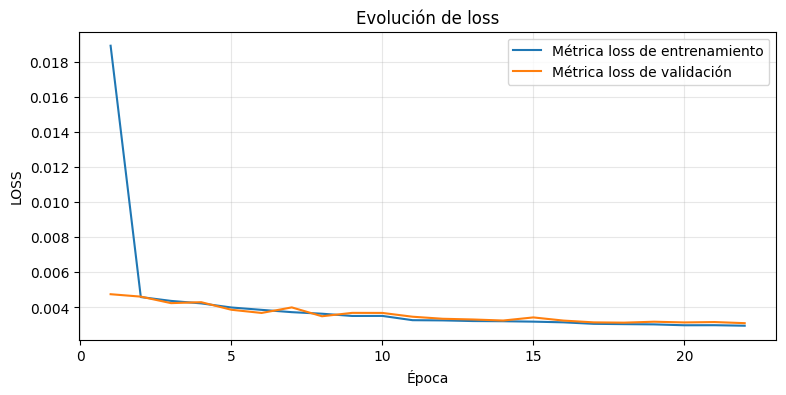

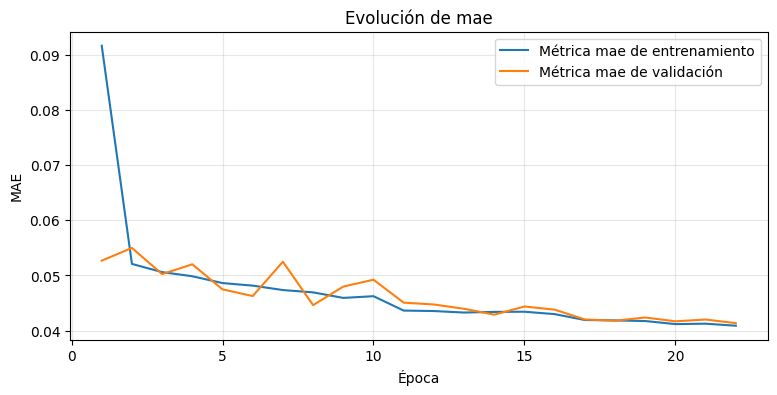

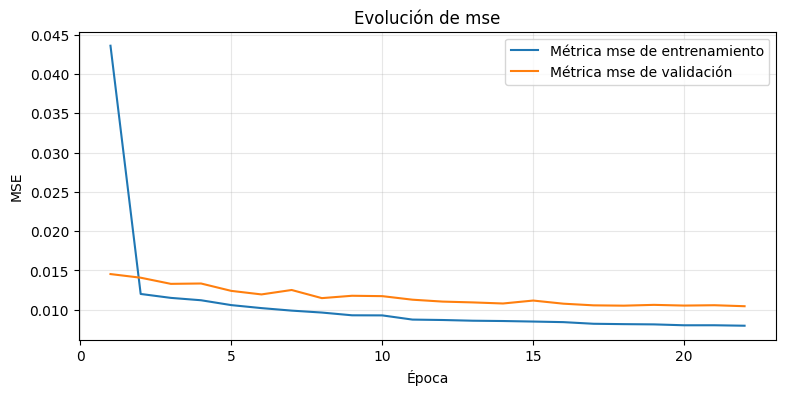

In [32]:
plot_training_metrics(model_data_median_spec)

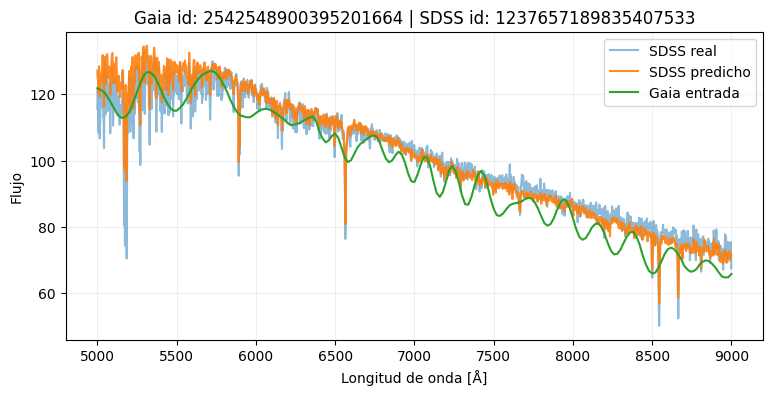

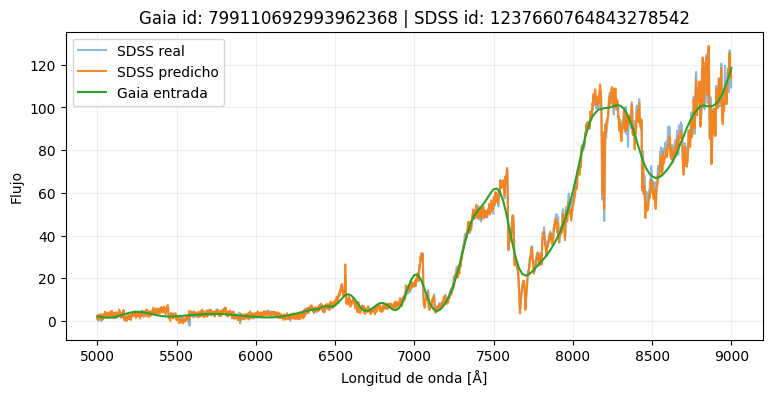

In [33]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_median_spec,
    y_id_test,
    X_test,
    X_id_test
)

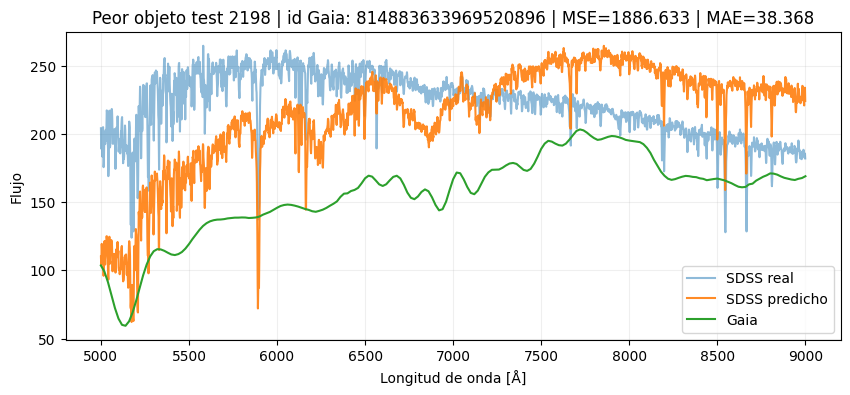

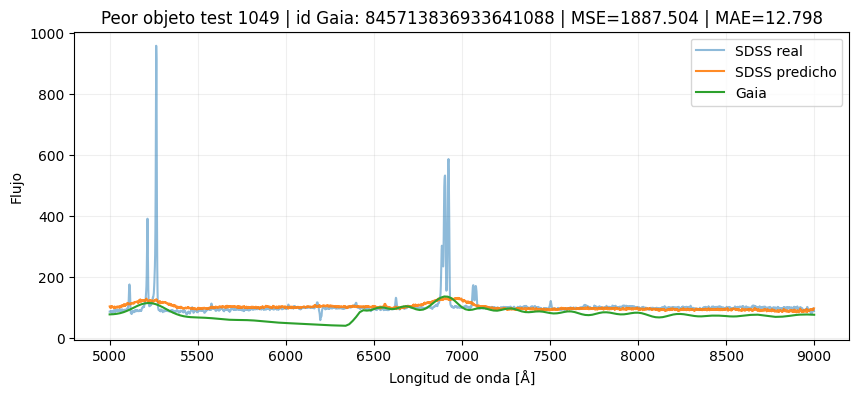

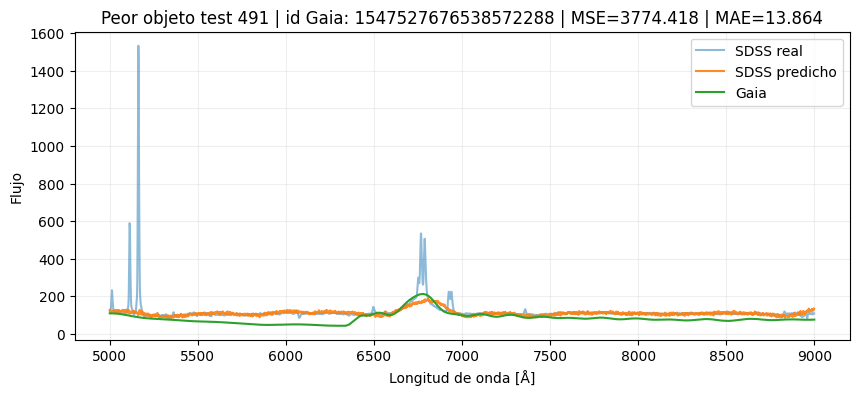

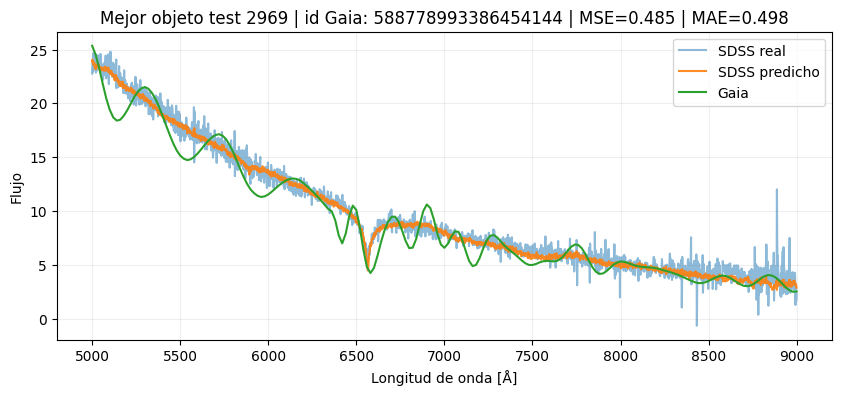

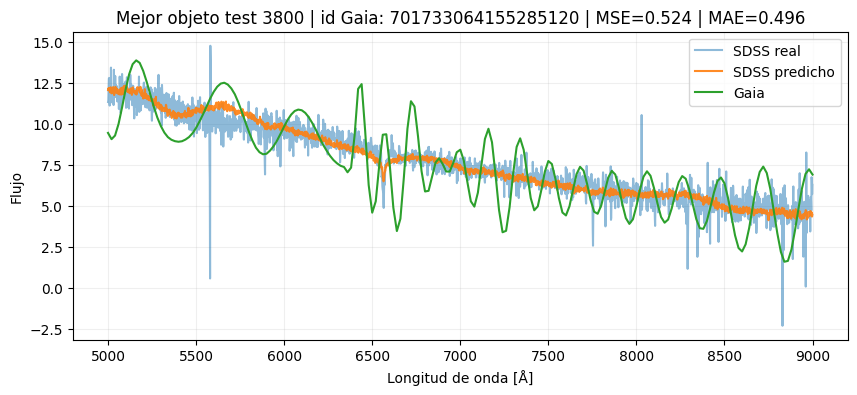

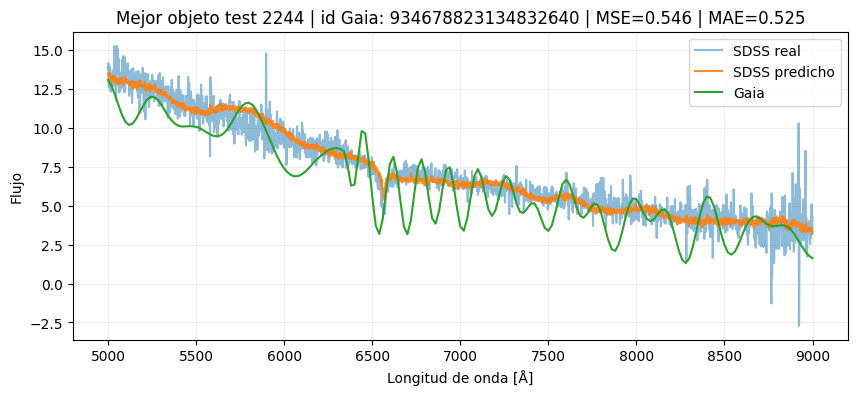

In [34]:
plot_worst_best_predictions(
    y_test,
    y_pred_median_spec,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

Igual que en el anterior caso, analizamos con iSpec

In [35]:
results_2_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_median_spec,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)
display(results_2_df)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real





Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-09-01 06:31:07,183] [WARNING] [atmospheres:_interpolate:110]: Target point '3500.0 2.3463175978174657 -4.695021592410095 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-01 06:31:08,293] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-01 06:31:15,580] [WARNING] [atmospheres:_interpolate:110]: Target point '3537.5422589916693 3.114681822694977 -4.524105442341513 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-01 06:31:16,688] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.
[2026-09-01 06:31:30,079] [WARNING] [atmospheres:_interpolate:110]: Target point '3598.1377425618134 2.685205851170036 -4.3724915977576195 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . 

Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Espectros analizados: 250 | ajustes del espectro real reutilizados: 250


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5190.837837,4.669266,-0.895610,-98.433551,-0.005730,0.009795
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5763.663316,4.672326,-1.132039,1.454857,-0.002984,-0.006404
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6041.120038,4.166240,-0.701166,6.351815,0.000500,-0.012479
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6026.277865,4.358598,-0.639696,-28.254160,-0.002971,0.252473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4807.114822,5.000000,-1.293156,14.590823,0.000000,0.099308
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5386.689180,4.704030,-0.995598,-31.649480,-0.015282,-0.006626
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5830.108008,4.586649,-0.951503,34.526421,-0.061107,0.019687
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5932.813396,4.638338,-1.154762,-11.571241,-0.068053,0.783177


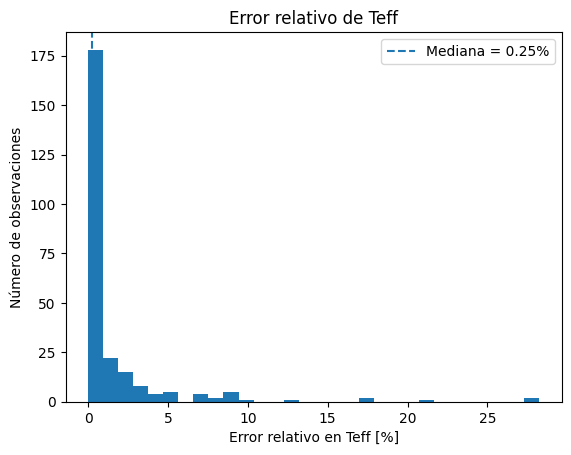

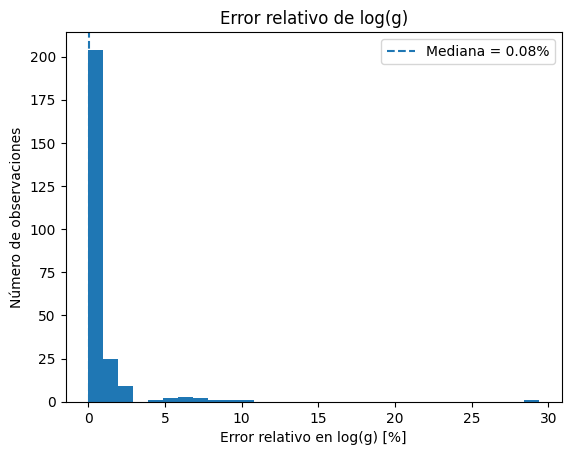

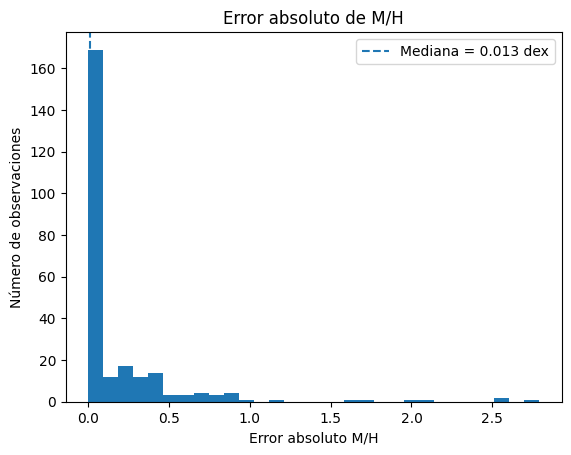

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5190.837837,4.669266,-0.895610,-98.433551,-0.005730,0.009795,98.433551,0.005730,0.009795,1.861004,0.122576
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5763.663316,4.672326,-1.132039,1.454857,-0.002984,-0.006404,1.454857,0.002984,0.006404,0.025248,0.063825
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6041.120038,4.166240,-0.701166,6.351815,0.000500,-0.012479,6.351815,0.000500,0.012479,0.105254,0.012009
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6026.277865,4.358598,-0.639696,-28.254160,-0.002971,0.252473,28.254160,0.002971,0.252473,0.466661,0.068112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4807.114822,5.000000,-1.293156,14.590823,0.000000,0.099308,14.590823,0.000000,0.099308,0.304450,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5386.689180,4.704030,-0.995598,-31.649480,-0.015282,-0.006626,31.649480,0.015282,0.006626,0.584118,0.323817
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5830.108008,4.586649,-0.951503,34.526421,-0.061107,0.019687,34.526421,0.061107,0.019687,0.595737,1.314762
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5932.813396,4.638338,-1.154762,-11.571241,-0.068053,0.783177,11.571241,0.068053,0.783177,0.194658,1.445978


In [36]:
error_2_df = analyze_ispec_errors(results_2_df)
display(error_2_df)

Misma estructura pero con normalización con el máximo por espectro.

In [37]:
# Máximo absoluto por espectro
X_max_train = np.nanmax(np.abs(X_train), axis=1, keepdims=True)
X_max_val = np.nanmax(np.abs(X_val), axis=1, keepdims=True)
X_max_test = np.nanmax(np.abs(X_test), axis=1, keepdims=True)

y_max_train = np.nanmax(np.abs(y_train), axis=1, keepdims=True)
y_max_val = np.nanmax(np.abs(y_val), axis=1, keepdims=True)
y_max_test = np.nanmax(np.abs(y_test), axis=1, keepdims=True)

# Normalización
X_train_norm_max = X_train / X_max_train
X_val_norm_max = X_val / X_max_val
X_test_norm_max = X_test / X_max_test

y_train_norm_max = y_train / y_max_train
y_val_norm_max = y_val / y_max_val
y_test_norm_max = y_test / y_max_test

In [38]:
# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# los estadísticos, en un solo paso.
save_test_data(
    MAX_TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_max_test=X_max_test,
    y_max_test=y_max_test
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max_test_data.npz')

In [39]:
# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_max_spectrum = ModelCheckpoint(
    MAX_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_max_spectrum = CSVLogger(MAX_HISTORY_PATH)

model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_max_spectrum,
        early_stop,
        reduce_lr,
        save_training_history_max_spectrum
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_per_spectrum_max.save(MAX_MODEL_PATH)

model_data_max = history_max_spectrum.history
save_training_summary(
    MAX_SUMMARY_PATH,
    model_data_max,
    model_path=MAX_MODEL_PATH,
    history_path=MAX_HISTORY_PATH,
    batch_size=batch_size
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0104 - mae: 0.0933 - mse: 0.0208
Epoch 1: val_loss improved from None to 0.00557, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/dense/dense-max.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step - loss: 0.0104 - mae: 0.0933 - mse: 0.0208 - val_loss: 0.0056 - val_mae: 0.0730 - val_mse: 0.0111 - learning_rate: 1.0000e-04
Epoch 2/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0052 - mae: 0.0701 - mse: 0.0104
Epoch 2: val_loss did not improve from 0.00557
511/511 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - loss: 0.0052 - mae: 0.0701 - mse: 0.0104 - val_loss: 0.0061 - val_mae: 0.0703 - val_mse: 0.0121 - learning_rate: 1.0000e-04
Epoch 3/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0050 - mae: 0.0683 - mse: 0.0100
Epoch 3: val_loss improved from 0.00557 to 

{'model': 'dense-max.keras',
 'history': 'dense-max_training_history.csv',
 'updated': '2026-09-01T07:17:41',
 'batch_size': 64,
 'epochs_completed': 20,
 'best_epoch': 20,
 'test_metrics': None}

Recarga desde el checkpoint del modelo con normalización por espectro con el máximo. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después esta, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [40]:
model_per_spectrum_max, model_data_max, summary_max = load_checkpoint(
    MAX_MODEL_PATH, MAX_HISTORY_PATH, MAX_SUMMARY_PATH
)

# Variables del conjunto de test que consumen las celdas siguientes
test_data = load_test_data(MAX_TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_max_test = test_data["X_max_test"]
y_max_test = test_data["y_max_test"]

# La normalización se rehace a partir de los estadísticos guardados, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_max = X_test / X_max_test
y_test_norm_max = y_test / y_max_test

print("Checkpoint de", summary_max["updated"])
print(
    "Épocas completadas:", summary_max["epochs_completed"],
    "| mejor época:", summary_max["best_epoch"]
)
print("Métricas de test:", summary_max["test_metrics"])

Checkpoint de 2026-09-01T07:17:41
Épocas completadas: 20 | mejor época: 20
Métricas de test: None


In [ ]:
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo con normalización por espectro con el máximo
y_pred_per_spectrum_max = predict_test_set(
    MAX_MODEL_PATH,
    MAX_TEST_DATA_PATH,
    build_input=lambda test: test["X_test"] / test["X_max_test"],
    denormalize=lambda y_norm, test: y_norm * test["y_max_test"]
)

save_predictions(MAX_PREDICTIONS_PATH, y_pred=y_pred_per_spectrum_max)

In [42]:
test_results_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    MAX_SUMMARY_PATH,
    model_data_max,
    test_results_max,
    model_path=MAX_MODEL_PATH,
    history_path=MAX_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_max)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0045 - mae: 0.0621 - mse: 0.0089
{'loss': 0.00447233859449625, 'mae': 0.06205585226416588, 'mse': 0.008945233188569546}


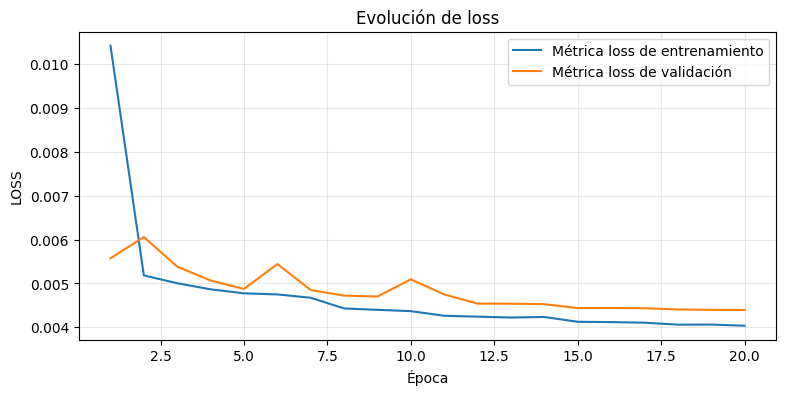

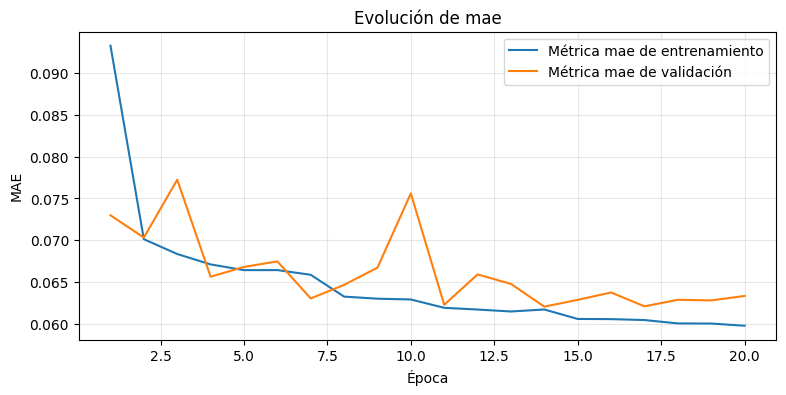

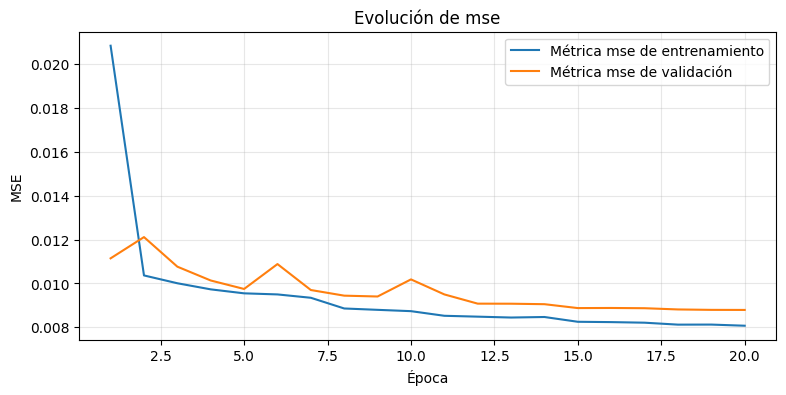

In [43]:
plot_training_metrics(model_data_max)


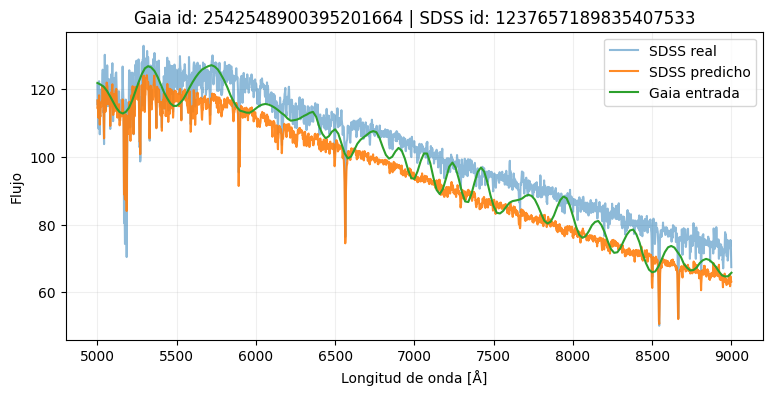

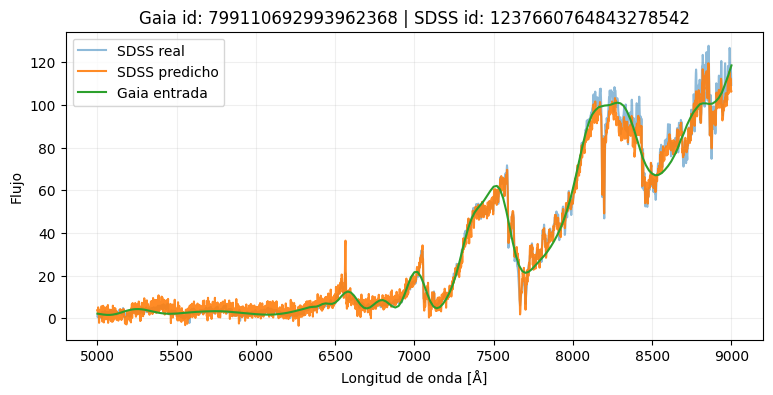

In [44]:
plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred_per_spectrum_max,
    y_id_test,
    X_test,
    X_id_test
)

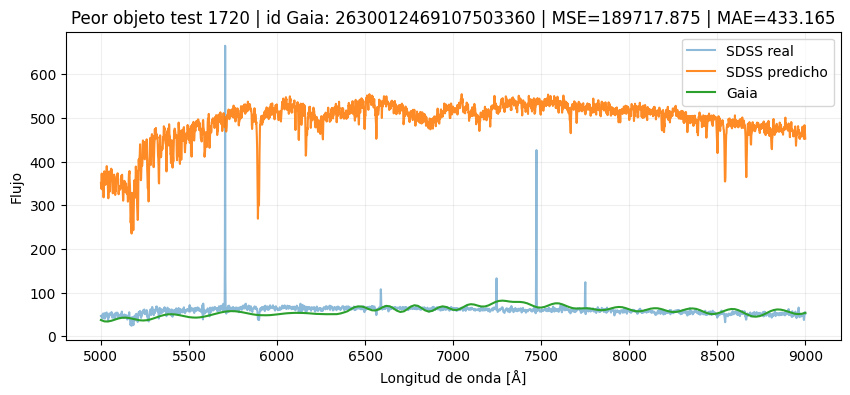

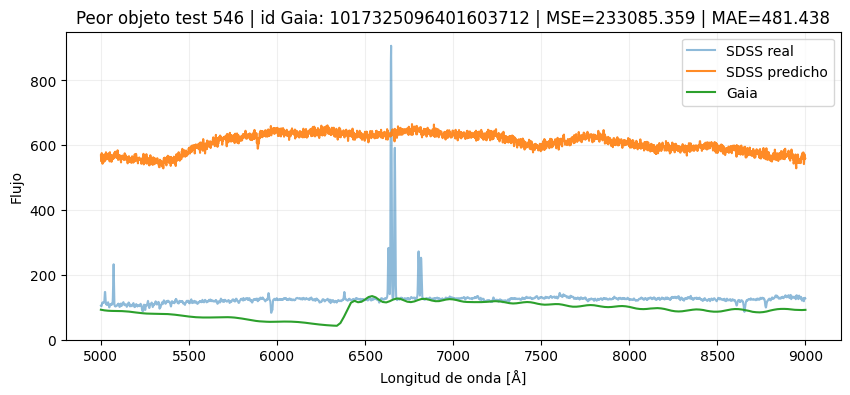

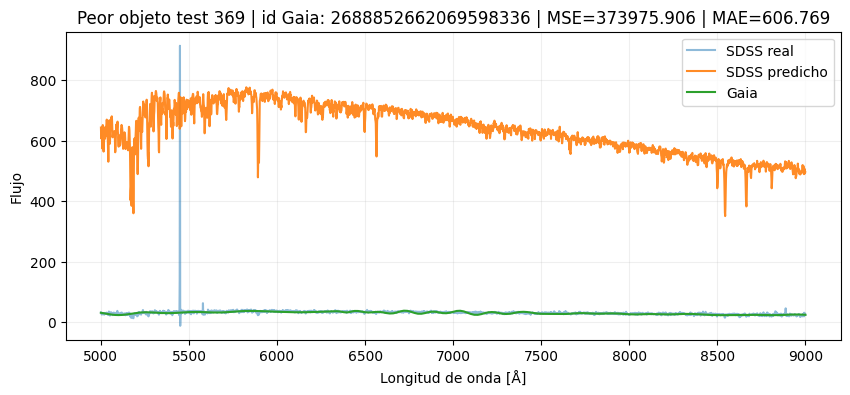

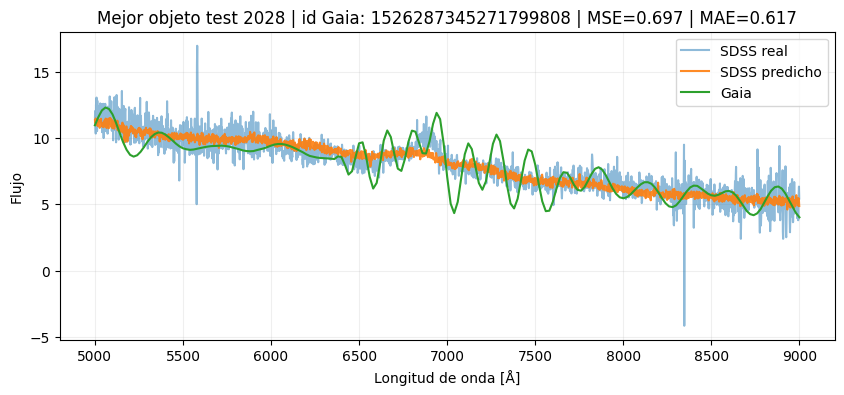

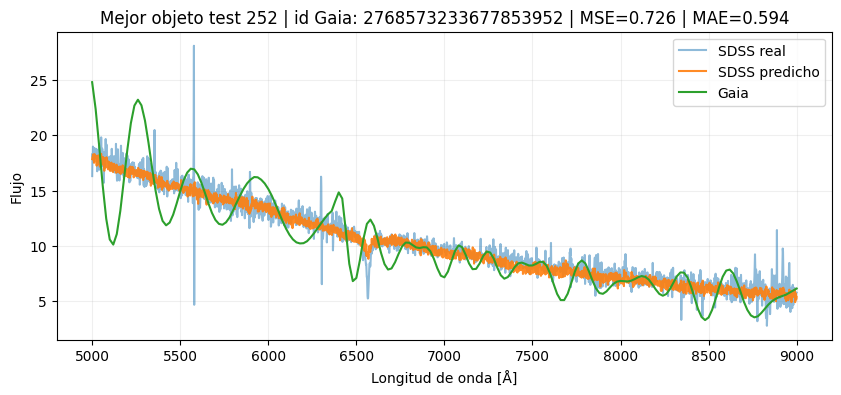

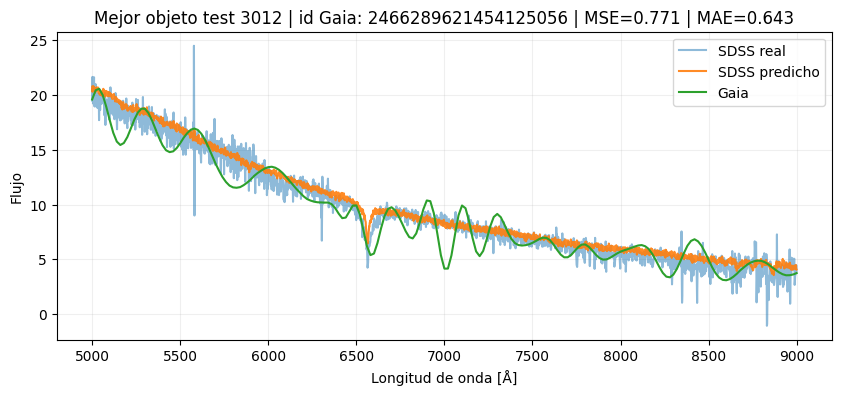

In [45]:
plot_worst_best_predictions(
    y_test,
    y_pred_per_spectrum_max,
    X_test,
    X_id_test,
    sdss_wavelength,
    gaia_wavelength,
    3
)

In [ ]:
results_3_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_per_spectrum_max,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)
display(results_3_df)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real




Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


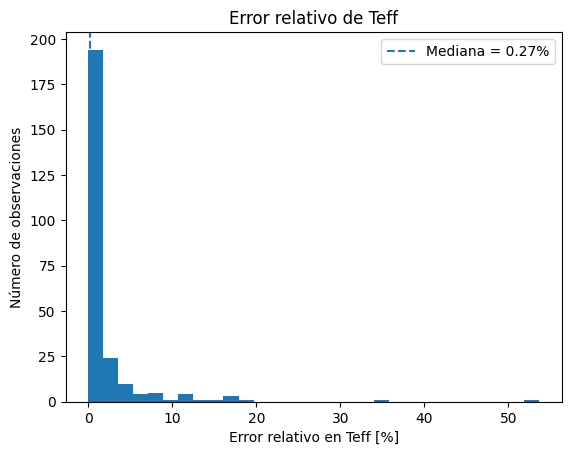

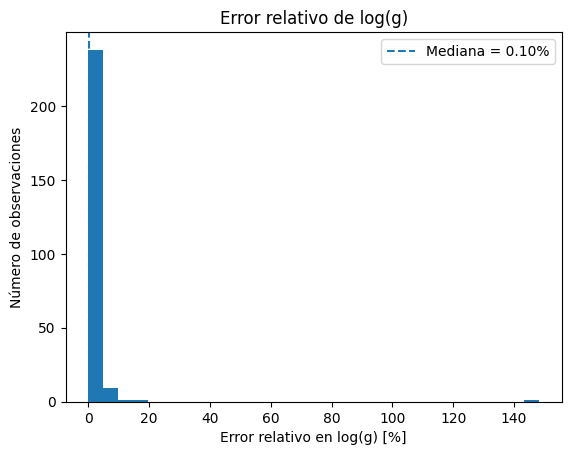

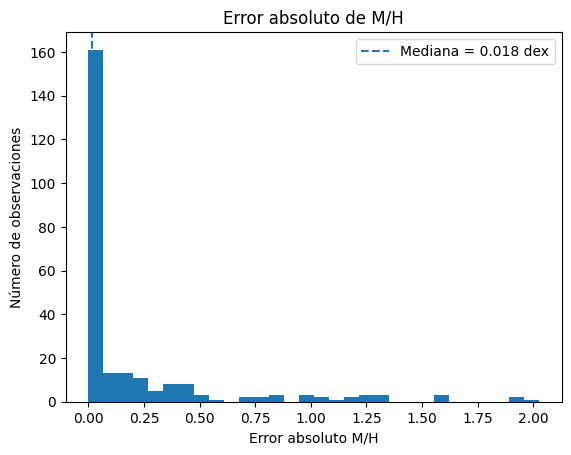

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5289.271388,4.674996,-0.905404,5285.846846,4.670244,-0.903540,-3.424542,-0.004752,0.001864,3.424542,0.004752,0.001864,0.064745,0.101649
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5762.208459,4.675310,-1.125634,5760.183393,4.677716,-1.118823,-2.025066,0.002406,0.006812,2.025066,0.002406,0.006812,0.035144,0.051461
2,1248,580515167071431424,6104.623047,4.6595,-1.1587,6105.328300,4.659957,-1.158281,6104.623047,4.659500,-1.158700,-0.705253,-0.000457,-0.000419,0.705253,0.000457,0.000419,0.011551,0.009806
3,3984,1548356295989132032,6033.668945,4.1655,-0.6890,6034.768224,4.165740,-0.688687,6035.124139,4.165912,-0.688956,0.355915,0.000173,-0.000269,0.355915,0.000173,0.000269,0.005898,0.004146
4,1597,147920842634097664,6010.371582,4.2697,-0.6194,6054.532026,4.361568,-0.892169,6060.498305,4.365430,-0.929024,5.966279,0.003862,-0.036855,5.966279,0.003862,0.036855,0.098542,0.088543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1612,1767906842245237376,4618.373047,4.6352,-0.2257,4792.523999,5.000000,-1.392463,4479.314334,5.000000,-1.771211,-313.209665,0.000000,-0.378748,313.209665,0.000000,0.378748,6.535380,0.000000
246,949,1291094592545363456,5384.086426,4.7029,-0.9961,5418.338661,4.719312,-0.988972,5497.266946,4.693309,-0.996134,78.928286,-0.026003,-0.007162,78.928286,0.026003,0.007162,1.456688,0.550993
247,1845,1385035148035879808,5772.183594,4.5346,-0.9531,5795.581587,4.647755,-0.971190,5813.932176,4.606845,-0.949519,18.350589,-0.040910,0.021671,18.350589,0.040910,0.021671,0.316631,0.880220
248,1982,795956503372372096,5929.191406,4.6283,-1.0623,5944.384637,4.706392,-1.937940,5997.130086,4.742288,-2.408758,52.745449,0.035897,-0.470818,52.745449,0.035897,0.470818,0.887316,0.762724


In [ ]:
error_3_df = analyze_ispec_errors(results_3_df)
display(error_3_df)

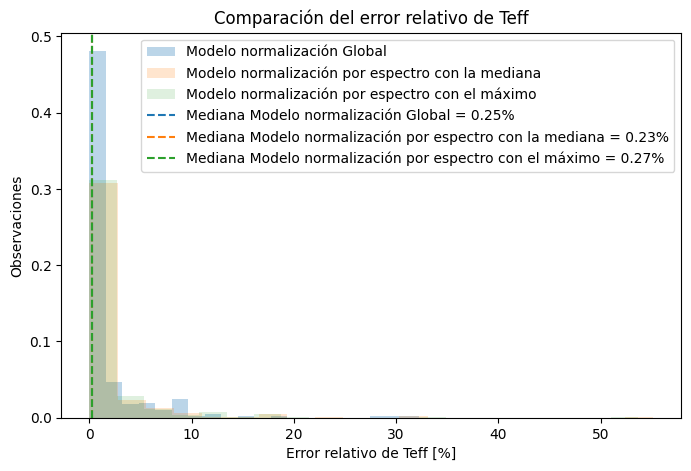

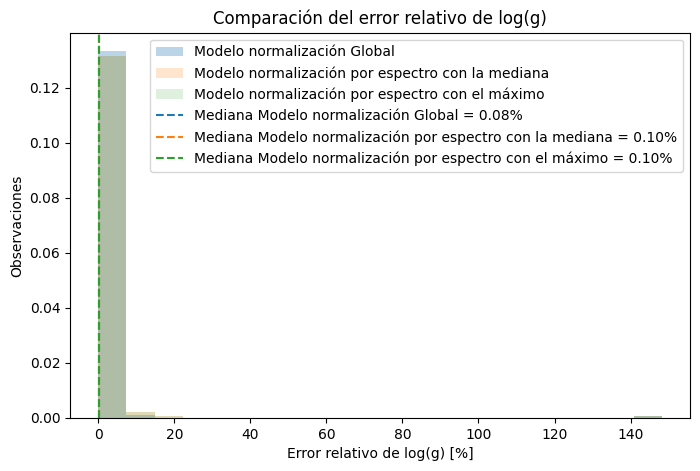

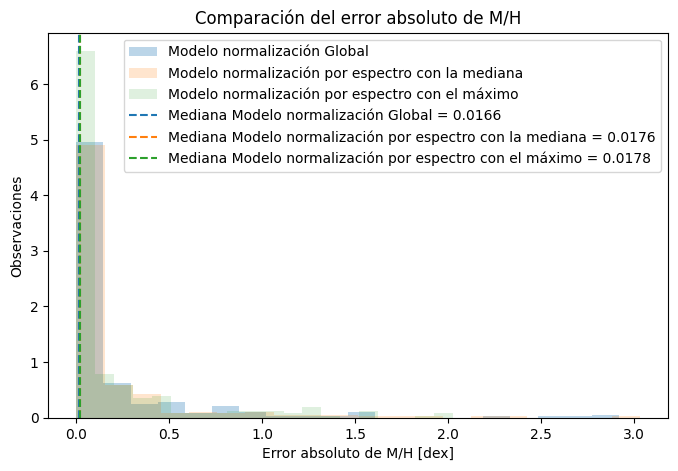

In [ ]:
# Ploteamos histograma para comparar modelos y errores
# Primero TEFF
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["rel_error_teff"].dropna(),
    bins=20,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["rel_error_teff"].dropna(),
    bins=20,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["rel_error_teff"].dropna(),
    bins=20,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_teff_global = error_df["rel_error_teff"].median()
median_teff_median = error_2_df["rel_error_teff"].median()
median_teff_max = error_3_df["rel_error_teff"].median()

plt.axvline(
    median_teff_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_teff_global:.2f}%"
)

plt.axvline(
    median_teff_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_teff_median:.2f}%"
)

plt.axvline(
    median_teff_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_teff_max:.2f}%"
)

plt.xlabel("Error relativo de Teff [%]")
plt.ylabel("Observaciones")
plt.title("Comparación del error relativo de Teff")
plt.legend()

plt.show()

# logg
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["rel_error_logg"].dropna(),
    bins=20,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["rel_error_logg"].dropna(),
    bins=20,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["rel_error_logg"].dropna(),
    bins=20,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_logg_global = error_df["rel_error_logg"].median()
median_logg_median = error_2_df["rel_error_logg"].median()
median_logg_max = error_3_df["rel_error_logg"].median()

plt.axvline(
    median_logg_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_logg_global:.2f}%"
)

plt.axvline(
    median_logg_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_logg_median:.2f}%"
)

plt.axvline(
    median_logg_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_logg_max:.2f}%"
)

plt.xlabel("Error relativo de log(g) [%]")
plt.ylabel("Observaciones")
plt.title("Comparación del error relativo de log(g)")
plt.legend()

plt.show()

# m/h
plt.figure(figsize=(8, 5))

plt.hist(
    error_df["abs_error_mh"].dropna(),
    bins=20,
    alpha=0.3,
    density=True,
    label="Modelo normalización Global"
)

plt.hist(
    error_2_df["abs_error_mh"].dropna(),
    bins=20,
    alpha=0.2,
    density=True,
    label="Modelo normalización por espectro con la mediana"
)

plt.hist(
    error_3_df["abs_error_mh"].dropna(),
    bins=20,
    alpha=0.15,
    density=True,
    label="Modelo normalización por espectro con el máximo"
)

median_MH_global = error_df["abs_error_mh"].median()
median_MH_median = error_2_df["abs_error_mh"].median()
median_MH_max = error_3_df["abs_error_mh"].median()

plt.axvline(
    median_MH_global,
    linestyle="--",
    color="C0",
    label=f"Mediana Modelo normalización Global = {median_MH_global:.4f}"
)

plt.axvline(
    median_MH_median,
    linestyle="--",
    color="C1",
    label=f"Mediana Modelo normalización por espectro con la mediana = {median_MH_median:.4f}"
)

plt.axvline(
    median_MH_max,
    linestyle="--",
    color="C2",
    label=f"Mediana Modelo normalización por espectro con el máximo = {median_MH_max:.4f}"
)

plt.xlabel("Error absoluto de M/H [dex]")
plt.ylabel("Observaciones")
plt.title("Comparación del error absoluto de M/H")
plt.legend()

plt.show()